# Funções Como Expressões

Uma característica importante da **Programação Funcional** é que a própria **definição de função** pode ser encarada como um **valor**, mais precisamente, uma **expressão**.

Como consequência, definição de **funções**, **valores** e **expressões** passam a ser tratados de forma igual dentro da linguagem em questão, compartilhando de propriedades absolutamente semelhantes.

Ou seja, Isso significa que funções podem ser manipuladas da mesma forma que:

*  números
*  strings
*  listas
*  conjuntos
*  dicionários

Isso "eleva" de fato o conceito de função para o mesmo nível de um valor ou expressão, ou seja, o mais importante nível de representatividade dentro da programação, os chamados **CIDADÃS DE PRIMEIRA CLASSE**.

Ou seja, uma função pode:

*   ser armazenada em variáveis
*   ser passada como argumento
*   ser retornada por outra função
*   ser armazenada em estruturas de dados
*   ser criada dinamicamente



Em Python, funções são tratadas como objetos completos da linguagem.



In [ ]:
# Armazenar Função em variável

def saudacao():
    return "Olá!"

mensagem = saudacao

print(mensagem())

Olá!


A variável mensagem não executa a função.

Apenas copia a referência da função para outra variável.

In [ ]:
# Passar Função como argumento

def executar(funcao):
    return funcao()

def ola():
    return "Oi"

print(executar(ola))

Oi


Aqui, a função é passada como um dado ou expressão

In [ ]:
# Retornar Função

def criar_multiplicador(n):

    def multiplicar(x):
        return x * n

    return multiplicar

dobrar = criar_multiplicador(2)

print(dobrar(10))

<function criar_multiplicador at 0x7a29476efc40>
20


Aqui a função *criar_multiplicador* retorna outra função como resultado

A variável *dobrar* faz referência a função *criar_multiplicador*, mas tem como resultado uma função parcial e não o resultado completo da função, pois todos os parâmetros não foram passados ainda. O resultado final acontece quando um novo parâmetro é adicionado a *dobrar*

In [ ]:
# O que aconteceria se for executado apenas print(dobrar)?

In [ ]:
# Guardar Funções em Listas

def soma(a, b):
    return a + b

def mult(a, b):
    return a * b

operacoes = [soma, mult]

print(operacoes[0](2, 3))
print(operacoes[1](2, 3))

<function soma at 0x7a29455a3ce0>
5
6


In [ ]:
# Funções criadas dinamicamente

def criar_operacao(tipo):

    if tipo == "soma":

        def somar(a, b):
            return a + b

        return somar

    else:

        def multiplicar(a, b):
            return a * b

        return multiplicar


op1 = criar_operacao("soma")
op2 = criar_operacao("multi")

print(op1(2, 3))
print(op2(2, 3))

5
6


# Funções de Alta Ordem

Se funções podem ser manipuladas como dados, como vimos anteriormente, então:

*  uma função pode receber outra função
*  uma função pode retornar outra função

**Funções de alta ordem** (ou *higher-order functions*) são funções que fazem pelo menos uma destas coisas:
1.   Recebem outras funções como argumento
2.   Retornam uma função como resultado

A relação direta entre Funções de Alta Ordem e Cidadãs de Prmeira Classe é a seguinte:


*   Funções como cidadãs de primeira classe são a capacidade da linguagem
*   Funções de alta ordem são uma consequência prática dessa capacidade

Uma linguagem consegue ter funções de alta ordem porque trata funções como cidadãs de primeira classe.

Esse conceito é muito usado em **Programação Funcional** e aparece bastante em linguagens como JavaScript, Python, Haskell, Kotlin, etc.

In [ ]:
# Exemplo simples de função de alta ordem

def executar(funcao, valor):
    return funcao(valor)

def dobro(x):
    return x * 2

print(executar(dobro, 10))

20


A função *executar* recebe outra função como parâmetro de entrada. Por isso ela é uma função de alta ordem

In [ ]:
#Exemplo um pouco mais rebuscado

def somar(a, b, c):
    return a + b + c


def multi(a, b):
    return a * b


# Recebe outra função como argumento
def executar(fn, *params):

    # Retorna uma nova função
    def retorno(texto_inicial):
        return f"{texto_inicial} {fn(*params)}!"

    return retorno

# A forma de passagems de parâmetro mudou
r1 = executar(somar, 4, 5, 6)("O resultado da soma é")
r2 = executar(multi, 30, 40)("O resultado da multiplicação é")

print(r1)
print(r2)

O resultado da soma é 15!
O resultado da multiplicação é 1200!


Aqui a função executar recebe além da função (*fn*), um conjunto de parâmetro sem quantidade definida (**params*)

Perceba que a função *retorno* também tem seus próprios parâmetros de entrada

In [ ]:
# O que aconteceria se os parâmetros da função retorno não forem passados?

# Expressões Lambda

Uma função lambda em python é uma **função anônima**, ou seja, uma função criada sem usar def e normalmente sem nome. Ai ideia é criar funções usando uma sintaxe compacta baseada em expressões.

As lambda ajudam nisso porque permitem:

*   criar funções rapidamente
*   passar funções como argumento
*   retornar funções dinamicamente
*   compor operações





In [ ]:
# Estrtura Geral
lambda parametros: expressao

In [ ]:
# Em vez de escrever assim:

def dobro(x):
    return x * 2


# Agora passamos a escrever assim:
dobro = lambda x: x * 2

O ponto importante teoricamente é: **lambda é uma expressão**, ou seja, ela produz um valor.

As lambdas só fazem sentido porque funções em Python são cidadãs de primeira classe

Ou seja, funções podem ser:

*  atribuídas
*  passadas
*  retornadas
*  armazenadas

In [ ]:
# lambda passada como argumento

def executar(fn, valor):
    return fn(valor)

resultado = executar(lambda x: x * 2, 10)

print(resultado)

20


In [ ]:
# Ordenação de dicionários com lambda

pessoas = [
    {"nome": "Ana", "idade": 30},
    {"nome": "João", "idade": 20}
]

ordenadoPorIdade = sorted(
    pessoas,
    key = lambda p: p["idade"]
)

ordenadoPorNome = sorted(
    pessoas,
    key = lambda p: p["nome"]
)

print(ordenadoPorIdade)
print(ordenadoPorNome)

[{'nome': 'João', 'idade': 20}, {'nome': 'Ana', 'idade': 30}]
[{'nome': 'Ana', 'idade': 30}, {'nome': 'João', 'idade': 20}]


### Limitações Importantes do lambda em Python

Python intencionalmente mantém lambda simples.

Só aceita:

*   uma única expressão

Não aceita:

*   múltiplas linhas
*   loops internos
*   atribuições
*   return
*   blocos complexos

### Exemplo prático

Escreva um programa para calcular o maior e o menor valor real das raízes de uma equação de segundo grau. A expressão genérica para cálculo das raízes é dada por:

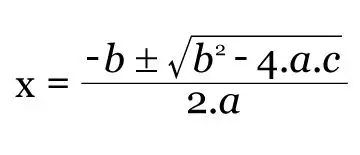

In [ ]:
import math

def raiz(a, b, c, f):
    delta = (b * b) - (4 * a * c)

    if delta < 0:
        return None

    pos = ((-b) + math.sqrt(delta)) / (2 * a)
    neg = ((-b) - math.sqrt(delta)) / (2 * a)

    return f(pos, neg)


num1 = 1
num2 = -5
num3 = 6

maior_raiz = raiz(num1, num2, num3, lambda x, y: x if x >= y else y)

menor_raiz = raiz(num1, num2, num3, lambda x, y: x if x <= y else y)


texto = lambda x, y: (
    "Não há raízes reais."
    if x is None
    else f"As raízes da equação são {x} e {y}."
)

print(texto(menor_raiz, maior_raiz))

As raízes da equação são 2.0 e 3.0.


# Material recomendado para leitura
*  [Expressões Lambda](https://docs.python.org/3/tutorial/controlflow.html#lambda-expressions)
*  [Programação Funcional em Python](https://docs.python.org/3/howto/functional.html)

# Exercícios

[Lista de exercícios](https://drive.google.com/file/d/1v-6auOarbwwlBJvmNUpxO-sh27I81FTo/view?usp=sharing)

